## ABSA DANA Experiment – IndoBERT-Lite

Notebook ini mereplikasi alur eksperimen paper **"Utilizing Sentiment Insights for Software Evaluation with Aspect-Based Sentiment Analysis in App Reviews Using IndoBERT-Lite"** menggunakan dataset `dana_app_reviews_downloaded.csv`.

Langkah utama yang dicakup:
- **Load dataset** dan auto-deteksi kolom teks ulasan
- **Labeling aspek** (design, functionality, performance, service, usability) dan **sentimen** (positive, neutral, negative) dengan opsi **manual** atau **otomatis/rule-based**
- **Preprocessing & tokenizing IndoBERT-Lite** (HuggingFace Transformers)
- **Split data 70/20/10** untuk train/validation/test
- **Pembuatan DataLoader** untuk PyTorch
- **Model IndoBERT-Lite multi-task** (klasifikasi aspek & sentimen)
- **Training** untuk beberapa batch size: 16, 32, 64
- **Evaluasi** (accuracy, precision, recall, F1, training time)
- **Visualisasi**: training vs validation loss, confusion matrix aspek & sentimen, stacked bar sentiment per aspect

> **Catatan:** Sebelum menjalankan seluruh notebook, pastikan environment memiliki paket: `torch`, `transformers`, `pandas`, `scikit-learn`, `matplotlib`, `seaborn`.


In [1]:
# Install (optional) & import libraries
# Jika beberapa paket belum ter-install, jalankan baris pip berikut (hapus komentar):
# !pip install torch torchvision torchaudio transformers pandas scikit-learn matplotlib seaborn

import os
import time
import random
import numpy as np
import pandas as pd

import torch
from torch.utils.data import Dataset, DataLoader
from torch import nn

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModel, AutoConfig, get_linear_schedule_with_warmup

# Konfigurasi umum
DATA_PATH = "dana_app_reviews_downloaded.csv"  # sesuaikan jika perlu
TEXT_COLUMN = None  # akan di-auto-detect jika None
LABELING_MODE = "auto_model"  # "rule_based" atau "manual" (lihat sel labeling)
MAX_LEN = 128
NUM_EPOCHS = 1
BATCH_SIZES = [16, 32, 64]
PRETRAINED_MODEL_NAME = "indobenchmark/indobert-base-p1"
SEED = 42

# Setup seed untuk reprodusibilitas
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# Load dataset & auto-deteksi kolom teks
assert os.path.exists(DATA_PATH), f"File tidak ditemukan: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Shape dataset:", df.shape)
print("Kolom:", df.columns.tolist())

# Auto-detect kolom teks: prioritas nama yang mengandung kata kunci umum review
if TEXT_COLUMN is None:
    text_like_cols = [
        c for c in df.columns
        if df[c].dtype == "object" or str(df[c].dtype).startswith("string")
    ]
    priority_keywords = ["review", "ulasan", "comment", "text", "content", "body"]
    chosen = None
    for kw in priority_keywords:
        for c in text_like_cols:
            if kw.lower() in c.lower():
                chosen = c
                break
        if chosen is not None:
            break
    if chosen is None and text_like_cols:
        chosen = text_like_cols[0]

    TEXT_COLUMN = chosen

print("Kolom teks yang digunakan:", TEXT_COLUMN)
assert TEXT_COLUMN is not None, "Tidak ditemukan kolom teks yang cocok. Set TEXT_COLUMN secara manual."

# Hapus baris dengan teks kosong/NaN
df = df.dropna(subset=[TEXT_COLUMN])
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str).str.strip()
df = df[df[TEXT_COLUMN] != ""]
print("Shape setelah bersih:", df.shape)

df.head()


Shape dataset: (50000, 5)
Kolom: ['userName', 'score', 'at', 'content', 'sentimen']
Kolom teks yang digunakan: content
Shape setelah bersih: (50000, 5)


,userName,score,at,content,sentimen
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE


In [13]:
# Labeling aspek & sentimen
# Aspek: design, functionality, performance, service, usability
# Sentimen: positive, neutral, negative

ASPECT_LABELS = ["design", "functionality", "performance", "service", "usability"]
SENTIMENT_LABELS = ["positive", "neutral", "negative"]

existing_aspect_col = None
existing_sentiment_col = None

for c in df.columns:
    cl = c.lower()
    if existing_aspect_col is None and ("aspect" in cl or "aspek" in cl):
        existing_aspect_col = c
    if existing_sentiment_col is None and ("sentiment" in cl or "sentimen" in cl or "label" in cl):
        existing_sentiment_col = c

print("Kolom aspek terdeteksi:", existing_aspect_col)
print("Kolom sentimen terdeteksi:", existing_sentiment_col)

# --- 1) SENTIMENT: selalu pakai kolom existing kalau ada ---
if existing_sentiment_col is not None:
    # mapping dari POSITIVE/NEGATIVE/NEUTRAL ke lowercase
    df["sentiment"] = (
        df[existing_sentiment_col]
        .astype(str)
        .str.upper()
        .map({
            "POSITIVE": "positive",
            "NEGATIVE": "negative",
            "NEUTRAL":  "neutral",
        })
    )
else:
    # fallback: kalau TIDAK ada kolom sentimen, baru pakai auto_model / rule-based
    if LABELING_MODE == "auto_model":
        print("Mode auto_model SENTIMENT tidak dipakai karena kolom 'sentimen' tidak ada.")
        # di sini bisa isi model_sentiment kalau suatu hari diperlukan
        raise ValueError("Tidak ada kolom sentimen di dataset; isi dulu atau aktifkan rule_based.")
    elif LABELING_MODE == "manual":
        df["sentiment"] = ""
    else:
        # rule_based sederhana jika mau
        def rule_based_sentiment(text: str) -> str:
            t = text.lower()
            positive_kw = ["bagus", "mantap", "keren", "puas", "suka", "terbaik", "helpful", "cepat"]
            negative_kw = ["jelek", "buruk", "parah", "kecewa", "kapok", "lemot", "error", "ribet", "lama"]
            pos = any(k in t for k in positive_kw)
            neg = any(k in t for k in negative_kw)
            if pos and not neg:
                return "positive"
            if neg and not pos:
                return "negative"
            return "neutral"
        df["sentiment"] = df[TEXT_COLUMN].astype(str).apply(rule_based_sentiment)

# --- 2) ASPECT: pakai existing kalau ada, kalau tidak pakai rule-based / manual ---

if existing_aspect_col is not None:
    df["aspect"] = df[existing_aspect_col].astype(str).str.lower().str.strip()
else:
    if LABELING_MODE == "manual":
        df["aspect"] = ""
        print("Mode manual: kolom 'aspect' dibuat kosong.")
    else:
        print("Aspect: rule-based heuristik.")
        def rule_based_aspect(text: str) -> str:
            t = text.lower()
            if any(k in t for k in ["tampilan", "desain", "design", "ui", "ux", "warna"]):
                return "design"
            if any(k in t for k in ["fitur", "fungsi", "function", "menu", "top up", "transfer", "bayar"]):
                return "functionality"
            if any(k in t for k in ["lemot", "lambat", "hang", "error", "bug", "force close", "crash", "loading"]):
                return "performance"
            if any(k in t for k in ["cs", "customer service", "layanan", "help center", "respon", "pelayanan"]):
                return "service"
            if any(k in t for k in ["mudah", "simple", "gampang", "ribet", "susah", "user friendly"]):
                return "usability"
            return "usability"
        df["aspect"] = df[TEXT_COLUMN].astype(str).apply(rule_based_aspect)

# Filter hanya label yang valid
df = df[df["aspect"].isin(ASPECT_LABELS) & df["sentiment"].isin(SENTIMENT_LABELS)]
print("Distribusi aspek:")
print(df["aspect"].value_counts())
print("\nDistribusi sentimen:")
print(df["sentiment"].value_counts())

df.head()

Kolom aspek terdeteksi: aspect
Kolom sentimen terdeteksi: sentimen
Distribusi aspek:
aspect
functionality    2000
usability        2000
service          1282
performance      1016
design            872
Name: count, dtype: int64

Distribusi sentimen:
sentiment
negative    4063
positive    2034
neutral     1073
Name: count, dtype: int64


,userName,score,at,content,sentimen,aspect,sentiment,aspect_id,sentiment_id,pair_label
0,Melkisedek Putra Harapan Hulu (MelkiHulu_D3 Ke...,4,2024-02-03 02:59:48,Semoga di update selanjutnya Dana bisa dipake ...,POSITIVE,functionality,positive,1,1,1_1
1,Moh. Wustadi,5,2024-02-04 01:49:43,aplikasi ini sangat membantu untuk kebutuhan s...,POSITIVE,service,positive,3,1,3_1
2,fajar mohamad,1,2024-02-06 16:52:51,jangan Download nanti uang kalian di gondol ma...,NEGATIVE,service,negative,3,1,3_1
3,Radi Mansyah,1,2024-01-16 09:12:48,Dana sekarang makin parah ajah Fitur vermuk aj...,NEGATIVE,functionality,negative,1,1,1_1
4,Hardi Ansyah,1,2024-01-25 11:13:37,Tiba tiba saldo kepotong tanpa ada pembelian a...,NEGATIVE,service,negative,3,1,3_1


In [14]:
# === Handling class imbalance dengan undersampling per (aspect, sentiment) pair ===

# Buat label gabungan untuk balancing
df["pair_label"] = df["aspect"] + "__" + df["sentiment"]

print("Distribusi awal pair_label:")
print(df["pair_label"].value_counts().head(20))

# Atur maksimum sampel per pair (silakan sesuaikan)
MAX_SAMPLES_PER_PAIR = 2000  # misal, tidak lebih dari 2000 data per (aspect, sentiment)

balanced_parts = []
for pair, count in df["pair_label"].value_counts().items():
    subset = df[df["pair_label"] == pair]
    if count > MAX_SAMPLES_PER_PAIR:
        subset = subset.sample(MAX_SAMPLES_PER_PAIR, random_state=SEED)
    balanced_parts.append(subset)

df_balanced = pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)
df = df_balanced.drop(columns=["pair_label"])

print("\nDistribusi aspek setelah balancing:")
print(df["aspect"].value_counts())
print("\nDistribusi sentimen setelah balancing:")
print(df["sentiment"].value_counts())

Distribusi awal pair_label:
pair_label
usability__positive        1169
functionality__negative    1118
performance__negative       860
service__negative           815
design__negative            676
usability__negative         594
functionality__positive     479
functionality__neutral      403
service__positive           276
usability__neutral          237
service__neutral            191
design__neutral             140
performance__neutral        102
design__positive             56
performance__positive        54
Name: count, dtype: int64

Distribusi aspek setelah balancing:
aspect
usability        2000
functionality    2000
service          1282
performance      1016
design            872
Name: count, dtype: int64

Distribusi sentimen setelah balancing:
sentiment
negative    4063
positive    2034
neutral     1073
Name: count, dtype: int64


In [15]:
# Encode label & split data 70/20/10

aspect2id = {a: i for i, a in enumerate(ASPECT_LABELS)}
id2aspect = {i: a for a, i in aspect2id.items()}

sentiment2id = {s: i for i, s in enumerate(SENTIMENT_LABELS)}
id2sentiment = {i: s for s, i in sentiment2id.items()}

df["aspect_id"] = df["aspect"].map(aspect2id)
df["sentiment_id"] = df["sentiment"].map(sentiment2id)

# Gabungan label untuk stratify
df["pair_label"] = df["aspect_id"].astype(str) + "_" + df["sentiment_id"].astype(str)

train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    random_state=SEED,
    stratify=df["pair_label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=1/3,  # 1/3 dari 30% = 10% total
    random_state=SEED,
    stratify=temp_df["pair_label"],
)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)


Train: (5019, 10) Val: (1434, 10) Test: (717, 10)


In [6]:
!pip install -U transformers sentencepiece

In [16]:
# Tokenizer & Dataset / DataLoader

from transformers import BertTokenizerFast, AutoModel, AutoConfig, get_linear_schedule_with_warmup

# gunakan tokenizer BERT yang eksplisit untuk IndoBERT-Lite
tokenizer = BertTokenizerFast.from_pretrained(PRETRAINED_MODEL_NAME)
# kalau masih bermasalah, pakai yang lambat (non-fast):
# from transformers import BertTokenizer
# tokenizer = BertTokenizer.from_pretrained(PRETRAINED_MODEL_NAME)

class ABSADataset(Dataset):
    def __init__(self, df, text_col, max_len):
        self.texts = df[text_col].astype(str).tolist()
        self.aspect_ids = df["aspect_id"].astype(int).tolist()
        self.sentiment_ids = df["sentiment_id"].astype(int).tolist()
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoding = tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "aspect_label": torch.tensor(self.aspect_ids[idx], dtype=torch.long),
            "sentiment_label": torch.tensor(self.sentiment_ids[idx], dtype=torch.long),
        }
        return item

train_dataset = ABSADataset(train_df, TEXT_COLUMN, MAX_LEN)
val_dataset = ABSADataset(val_df, TEXT_COLUMN, MAX_LEN)
test_dataset = ABSADataset(test_df, TEXT_COLUMN, MAX_LEN)

print("Contoh item:")
example = train_dataset[0]
for k, v in example.items():
    print(k, v.shape if hasattr(v, "shape") else v)


Contoh item:
input_ids torch.Size([128])
attention_mask torch.Size([128])
aspect_label torch.Size([])
sentiment_label torch.Size([])


In [17]:
# Definisi model IndoBERT-Lite multi-task (aspek & sentimen)

class IndoBertABSA(nn.Module):
    def __init__(self, pretrained_name, num_aspect_labels, num_sentiment_labels, dropout=0.1):
        super().__init__()
        self.config = AutoConfig.from_pretrained(pretrained_name)
        self.bert = AutoModel.from_pretrained(pretrained_name, config=self.config)
        hidden_size = self.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.aspect_classifier = nn.Linear(hidden_size, num_aspect_labels)
        self.sentiment_classifier = nn.Linear(hidden_size, num_sentiment_labels)

    def forward(self, input_ids, attention_mask, labels_aspect=None, labels_sentiment=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # Gunakan pooled output (CLS)
        pooled = outputs.last_hidden_state[:, 0]
        pooled = self.dropout(pooled)

        logits_aspect = self.aspect_classifier(pooled)
        logits_sentiment = self.sentiment_classifier(pooled)

        loss = None
        if labels_aspect is not None and labels_sentiment is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss_aspect = loss_fct(logits_aspect, labels_aspect)
            loss_sentiment = loss_fct(logits_sentiment, labels_sentiment)
            loss = loss_aspect + loss_sentiment

        return {
            "loss": loss,
            "logits_aspect": logits_aspect,
            "logits_sentiment": logits_sentiment,
        }

# Fungsi utilitas training & evaluasi

def create_dataloaders(batch_size):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


def compute_metrics(y_true, y_pred, label_names):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    # pastikan jumlah kelas = len(label_names), walaupun di y_true/y_pred cuma muncul 1–2 kelas
    labels = list(range(len(label_names)))
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=label_names,
        zero_division=0,
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "report": report,
    }

def evaluate_model(model, data_loader):
    model.eval()
    all_aspect_true, all_aspect_pred = [], []
    all_sent_true, all_sent_pred = [], []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            aspect_labels = batch["aspect_label"].to(device)
            sentiment_labels = batch["sentiment_label"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
            )

            aspect_logits = outputs["logits_aspect"]
            sentiment_logits = outputs["logits_sentiment"]

            aspect_preds = torch.argmax(aspect_logits, dim=1).cpu().numpy()
            sent_preds = torch.argmax(sentiment_logits, dim=1).cpu().numpy()

            all_aspect_true.extend(aspect_labels.cpu().numpy())
            all_aspect_pred.extend(aspect_preds)
            all_sent_true.extend(sentiment_labels.cpu().numpy())
            all_sent_pred.extend(sent_preds)

    aspect_metrics = compute_metrics(all_aspect_true, all_aspect_pred, ASPECT_LABELS)
    sent_metrics = compute_metrics(all_sent_true, all_sent_pred, SENTIMENT_LABELS)

    return aspect_metrics, sent_metrics, {
        "aspect_true": np.array(all_aspect_true),
        "aspect_pred": np.array(all_aspect_pred),
        "sent_true": np.array(all_sent_true),
        "sent_pred": np.array(all_sent_pred),
    }


In [18]:
# Loop training untuk beberapa batch size (16, 32, 64)

results_per_batchsize = {}
train_histories = {}
val_histories = {}
state_dicts = {}

for bs in BATCH_SIZES:
    print("\n=============================")
    print(f"Training dengan batch size = {bs}")
    print("=============================")

    train_loader, val_loader, test_loader = create_dataloaders(bs)
    model = IndoBertABSA(
        pretrained_name=PRETRAINED_MODEL_NAME,
        num_aspect_labels=len(ASPECT_LABELS),
        num_sentiment_labels=len(SENTIMENT_LABELS),
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
    total_steps = len(train_loader) * NUM_EPOCHS
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    best_val_f1 = 0.0
    history_train_loss = []
    history_val_loss = []
    start_time = time.time()

    for epoch in range(1, NUM_EPOCHS + 1):
        start_epoch = time.time()
        print(f"Epoch {epoch}/{NUM_EPOCHS}")
        # Training
        model.train()
        running_loss = 0.0

        for step, batch in enumerate(train_loader, start=1):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            aspect_labels = batch["aspect_label"].to(device)
            sentiment_labels = batch["sentiment_label"].to(device)

            optimizer.zero_grad()
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels_aspect=aspect_labels,
                labels_sentiment=sentiment_labels,
            )

            loss = outputs["loss"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()

            # progress per 100 batch (ubah 100 kalau mau lebih/kurang sering)
            if step % 100 == 0 or step == len(train_loader):
                print(f"  Step {step}/{len(train_loader)} - loss {loss.item():.4f}")

        print(f"Epoch {epoch} selesai dalam {time.time() - start_epoch:.1f} detik")

        avg_train_loss = running_loss / max(1, len(train_loader))

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch["input_ids"].to(device)
                attention_mask = batch["attention_mask"].to(device)
                aspect_labels = batch["aspect_label"].to(device)
                sentiment_labels = batch["sentiment_label"].to(device)

                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    labels_aspect=aspect_labels,
                    labels_sentiment=sentiment_labels,
                )
                loss = outputs["loss"]
                val_loss += loss.item()

        avg_val_loss = val_loss / max(1, len(val_loader))
        history_train_loss.append(avg_train_loss)
        history_val_loss.append(avg_val_loss)

        print(f"Train loss: {avg_train_loss:.4f} | Val loss: {avg_val_loss:.4f}")

        # Evaluasi di validation set untuk F1 (sentimen)
        aspect_metrics, sent_metrics, _ = evaluate_model(model, val_loader)
        print("Val Sentiment F1:", sent_metrics["f1"])  # bisa juga lihat aspek

        if sent_metrics["f1"] > best_val_f1:
            best_val_f1 = sent_metrics["f1"]
            state_dicts[bs] = model.state_dict()

    total_time = time.time() - start_time

    # Load best model untuk evaluasi final di test set
    best_model = IndoBertABSA(
        pretrained_name=PRETRAINED_MODEL_NAME,
        num_aspect_labels=len(ASPECT_LABELS),
        num_sentiment_labels=len(SENTIMENT_LABELS),
    ).to(device)
    best_model.load_state_dict(state_dicts[bs])

    aspect_metrics_test, sent_metrics_test, preds = evaluate_model(best_model, test_loader)

    results_per_batchsize[bs] = {
        "aspect_metrics_test": aspect_metrics_test,
        "sent_metrics_test": sent_metrics_test,
        "train_time_sec": total_time,
        "preds": preds,
    }
    train_histories[bs] = history_train_loss
    val_histories[bs] = history_val_loss

    print("\n=== Hasil Test (Batch size =", bs, ") ===")
    print("Aspect metrics:")
    print(aspect_metrics_test["report"])
    print("Sentiment metrics:")
    print(sent_metrics_test["report"])
    print("Training time (s):", total_time)


Training dengan batch size = 16
Epoch 1/1
  Step 100/314 - loss 1.5839
  Step 200/314 - loss 0.8121
  Step 300/314 - loss 1.3162
  Step 314/314 - loss 1.7785
Epoch 1 selesai dalam 112.7 detik
Train loss: 1.1001 | Val loss: 0.6955
Val Sentiment F1: 0.8413049758079485

=== Hasil Test (Batch size = 16 ) ===
Aspect metrics:
               precision    recall  f1-score   support

       design       0.79      0.57      0.66        88
functionality       0.88      0.90      0.89       200
  performance       0.92      0.97      0.94       101
      service       0.92      0.98      0.95       128
    usability       0.89      0.93      0.91       200

     accuracy                           0.89       717
    macro avg       0.88      0.87      0.87       717
 weighted avg       0.89      0.89      0.89       717

Sentiment metrics:
              precision    recall  f1-score   support

    positive       0.86      0.86      0.86       204
     neutral       0.73      0.45      0.55       1

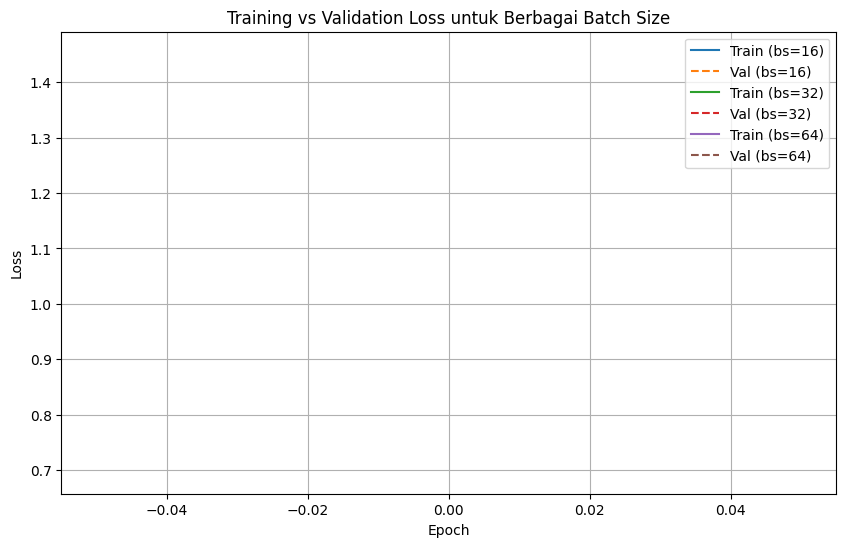

Batch size terbaik (berdasarkan F1 sentimen test): 16 (F1 = 0.8341)


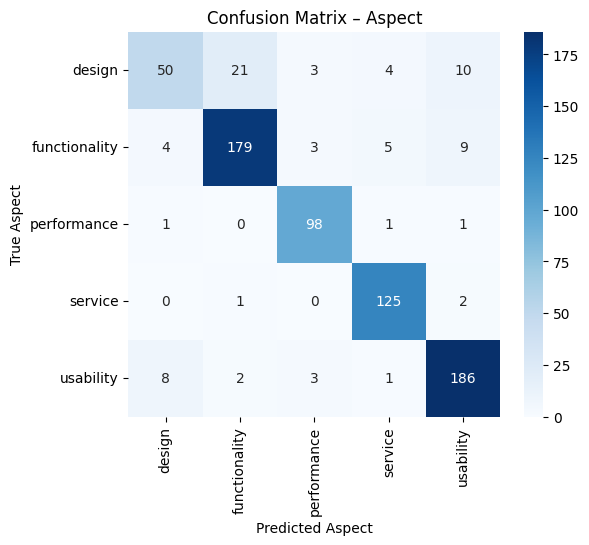

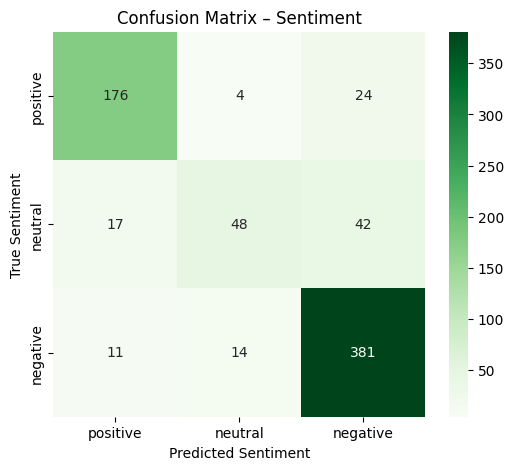

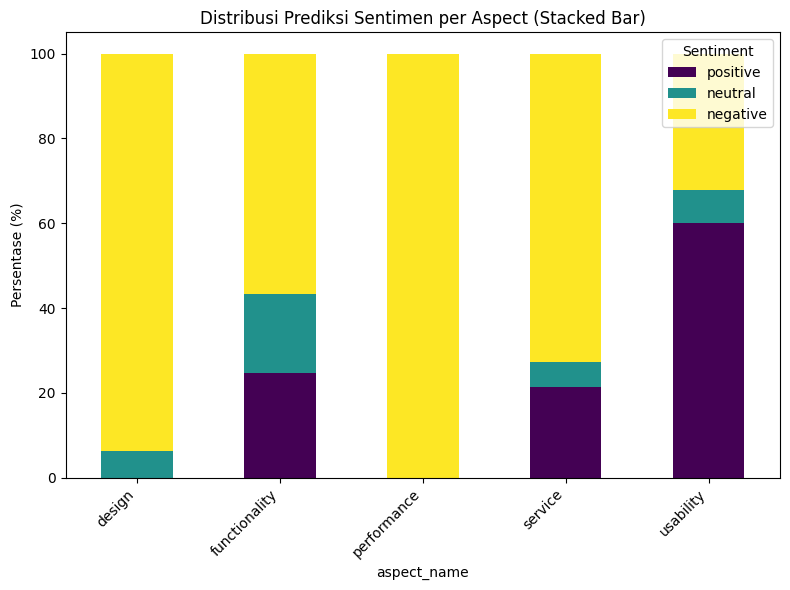

In [19]:
# Visualisasi: loss curves, confusion matrix, dan stacked bar sentiment per aspect

# 1. Plot training vs validation loss per batch size
plt.figure(figsize=(10, 6))
for bs in BATCH_SIZES:
    if bs in train_histories:
        plt.plot(train_histories[bs], label=f"Train (bs={bs})")
        plt.plot(val_histories[bs], linestyle="--", label=f"Val (bs={bs})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss untuk Berbagai Batch Size")
plt.legend()
plt.grid(True)
plt.show()

# Pilih batch size terbaik berdasarkan F1 sentimen di test
best_bs = None
best_f1 = -1
for bs in BATCH_SIZES:
    if bs in results_per_batchsize:
        f1_bs = results_per_batchsize[bs]["sent_metrics_test"]["f1"]
        if f1_bs > best_f1:
            best_f1 = f1_bs
            best_bs = bs

print(f"Batch size terbaik (berdasarkan F1 sentimen test): {best_bs} (F1 = {best_f1:.4f})")

best_preds = results_per_batchsize[best_bs]["preds"]

# 2. Confusion matrix untuk aspek
cm_aspect = confusion_matrix(best_preds["aspect_true"], best_preds["aspect_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_aspect, annot=True, fmt="d", cmap="Blues",
            xticklabels=ASPECT_LABELS, yticklabels=ASPECT_LABELS)
plt.xlabel("Predicted Aspect")
plt.ylabel("True Aspect")
plt.title("Confusion Matrix – Aspect")
plt.show()

# 3. Confusion matrix untuk sentimen
cm_sent = confusion_matrix(best_preds["sent_true"], best_preds["sent_pred"])
plt.figure(figsize=(6, 5))
sns.heatmap(cm_sent, annot=True, fmt="d", cmap="Greens",
            xticklabels=SENTIMENT_LABELS, yticklabels=SENTIMENT_LABELS)
plt.xlabel("Predicted Sentiment")
plt.ylabel("True Sentiment")
plt.title("Confusion Matrix – Sentiment")
plt.show()

# 4. Stacked bar: distribusi prediksi sentimen per aspek

# Buat DataFrame dari prediksi terbaik
df_preds = pd.DataFrame({
    "aspect_true": best_preds["aspect_true"],
    "aspect_pred": best_preds["aspect_pred"],
    "sent_true": best_preds["sent_true"],
    "sent_pred": best_preds["sent_pred"],
})

# Gunakan prediksi aspek & sentimen (bisa juga pakai true jika ingin)
df_preds["aspect_name"] = df_preds["aspect_pred"].map(id2aspect)
df_preds["sentiment_name"] = df_preds["sent_pred"].map(id2sentiment)

sent_counts = df_preds.groupby(["aspect_name", "sentiment_name"]).size().unstack(fill_value=0)

# Normalisasi ke persentase per aspek
sent_pct = sent_counts.div(sent_counts.sum(axis=1), axis=0) * 100

sent_pct[SENTIMENT_LABELS].plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6),
    colormap="viridis",
)
plt.ylabel("Persentase (%)")
plt.title("Distribusi Prediksi Sentimen per Aspect (Stacked Bar)")
plt.legend(title="Sentiment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
